In [ ]:
%pip install rohub pandas

In [106]:
import rohub

USE_DEVELOPMENT_VERSION = True

In [108]:
if USE_DEVELOPMENT_VERSION:
    rohub.settings.API_URL = "ttps://rohub2020-devel.apps.bst2.paas.psnc.pl/api/"
    rohub.settings.KEYCLOAK_CLIENT_ID = "rohub2020-cli"
    rohub.settings.KEYCLOAK_CLIENT_SECRET = "714617a7-87bc-4a88-8682-5f9c2f60337d"
    rohub.settings.KEYCLOAK_URL = "https://keycloak-dev.apps.paas-dev.psnc.pl/auth/realms/rohub/protocol/openid-connect/token"
    rohub.settings.SPARQL_ENDPOINT = "https://virtuoso-rohub2020-devel.apps.bst2.paas.psnc.pl/sparql"
else:
    rohub.settings.API_URL = "https://api.rohub.org/api/"
    rohub.settings.KEYCLOAK_CLIENT_ID = "rohub2020-public-cli"
    rohub.settings.KEYCLOAK_URL = "https://login.rohub.org/auth/realms/rohub/protocol/openid-connect/token"
    rohub.settings.SPARQL_ENDPOINT = "https://virtuoso-rohub2020-production.apps.bst2.paas.psnc.pl/sparql"

In [ ]:
username = ""
password = ""

rohub.login(username=username, password=password)

Logged successfully as mahdi.jafarkhani@gmail.com.


In [112]:
ANNOTATION_PREDICATE = "http://w3id.org/nfdi4ing/metadata4ing#investigates"
ANNOTATION_OBJECT = "https://github.com/Simulation-Benchmarks/linear-elastic-plate-with-hole"

In [113]:
UUID_QUERY = f"""
SELECT ?subject 
WHERE {{
  ?subject <{ANNOTATION_PREDICATE}> <{ANNOTATION_OBJECT}> .
}}
"""

uuid_result = rohub.query_sparql_endpoint(UUID_QUERY, endpoint_url=rohub.settings.SPARQL_ENDPOINT)
uuids = []

if not uuid_result.empty:
    uuids = [iri.split('/')[-1] for iri in uuid_result["subject"]]
    print("UUIDs:", uuids)
else:
    uuids = []
    print("No results found")

UUIDs: ['d85c2b87-05d1-4cea-906e-842fb2566505', '5740bc82-0ab2-4cf9-ace6-f45d076779c6']


In [114]:
named_graphs = {}

for UUID in uuids:
    RO_ID_BASE = "ro-id-dev" if USE_DEVELOPMENT_VERSION else "ro-id"
    NAMED_GRAPH_QUERY = f"""
    PREFIX schema: <http://schema.org/>
    SELECT ?graph WHERE {{
        GRAPH ?graph {{ <https://w3id.org/{RO_ID_BASE}/{UUID}> a schema:Dataset . }}
    }}
    """

    named_graph_result = rohub.query_sparql_endpoint(NAMED_GRAPH_QUERY, endpoint_url=rohub.settings.SPARQL_ENDPOINT)

    if not named_graph_result.empty:
        graph_iri = named_graph_result.iloc[0]["graph"]
        named_graphs[UUID] = graph_iri
        print(f"[{UUID}] Found Named Graph: {graph_iri}")

[d85c2b87-05d1-4cea-906e-842fb2566505] Found Named Graph: https://w3id.org/ro-id-dev/d85c2b87-05d1-4cea-906e-842fb2566505/.ro/annotations/7359d6b2-d33b-46ca-91cd-ba23a0d17b97.ttl
[5740bc82-0ab2-4cf9-ace6-f45d076779c6] Found Named Graph: https://w3id.org/ro-id-dev/5740bc82-0ab2-4cf9-ace6-f45d076779c6/.ro/annotations/3903888b-dff6-44e7-8fa3-a935edeafdf8.ttl


In [116]:
import sys
import os
import importlib
import pandas as pd

provenance_path = os.path.abspath(os.path.join('..', 'provenance'))

import provenance

if provenance_path not in sys.path:
    sys.path.append(provenance_path)
        
importlib.reload(provenance)
analyzer = provenance.ProvenanceAnalyzer()

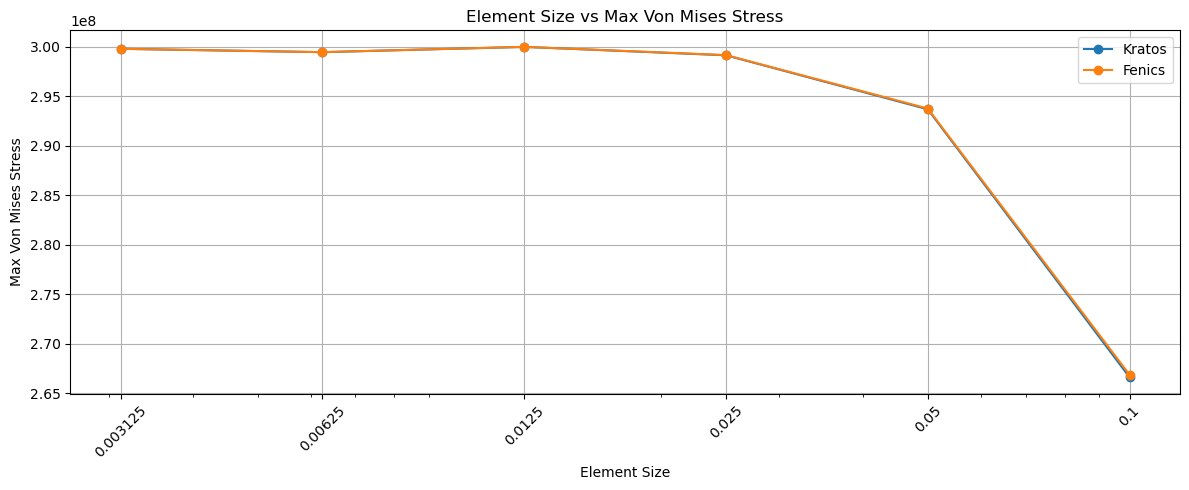

In [117]:
parameters = ["element_size", "isoparametric_element_degree"]
metrics = ["max_von_mises_stress"]

data = []

query_string = analyzer.build_dynamic_rohub_query(parameters, metrics, named_graphs.values())

df = rohub.query_sparql_endpoint(query_string, endpoint_url=rohub.settings.SPARQL_ENDPOINT)
result =  (df[df["isoparametric_element_degree"] == "1"].drop(columns=["isoparametric_element_degree"]))

analyzer.plot_provenance_graph_rohub(
    data=result.values.tolist(),
    x_axis_label="Element Size",
    y_axis_label="Max Von Mises Stress",
    group_index=0,
    x_axis_index=1,
    y_axis_index=2,
    title="Element Size vs Max Von Mises Stress",
)

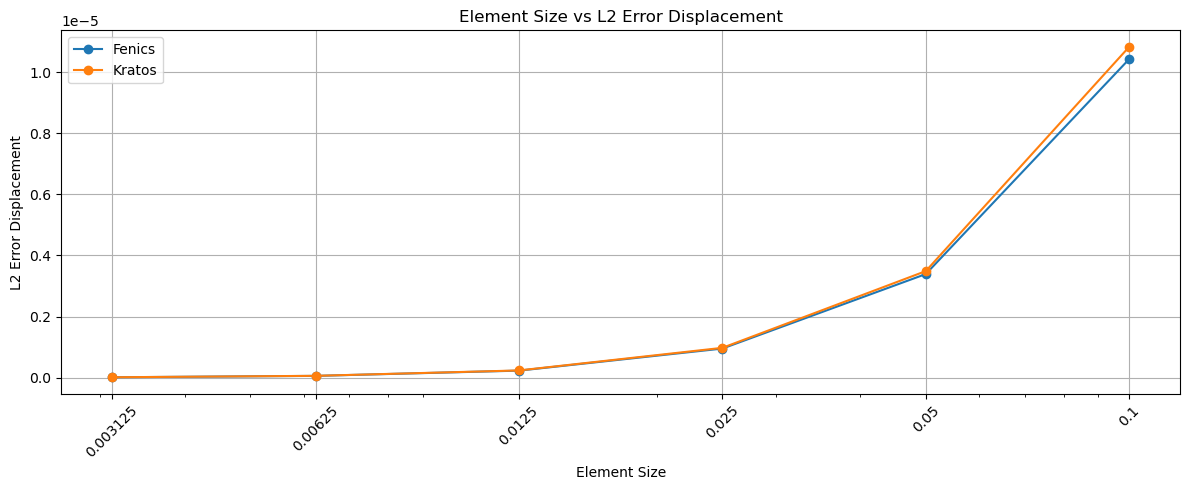

In [119]:
parameters = ["element_size", "isoparametric_element_degree"]
metrics = ["l2_error_displacement"]

data = []

query_string = analyzer.build_dynamic_rohub_query(parameters, metrics, named_graphs.values())
df = rohub.query_sparql_endpoint(query_string, endpoint_url=rohub.settings.SPARQL_ENDPOINT)
result =  (df[df["isoparametric_element_degree"] == "1"].drop(columns=["isoparametric_element_degree"]))

analyzer.plot_provenance_graph_rohub(
    data=result.values.tolist(),
    x_axis_label="Element Size",
    y_axis_label="L2 Error Displacement",
    group_index=0,
    x_axis_index=1,
    y_axis_index=2,
    title="Element Size vs L2 Error Displacement",
)

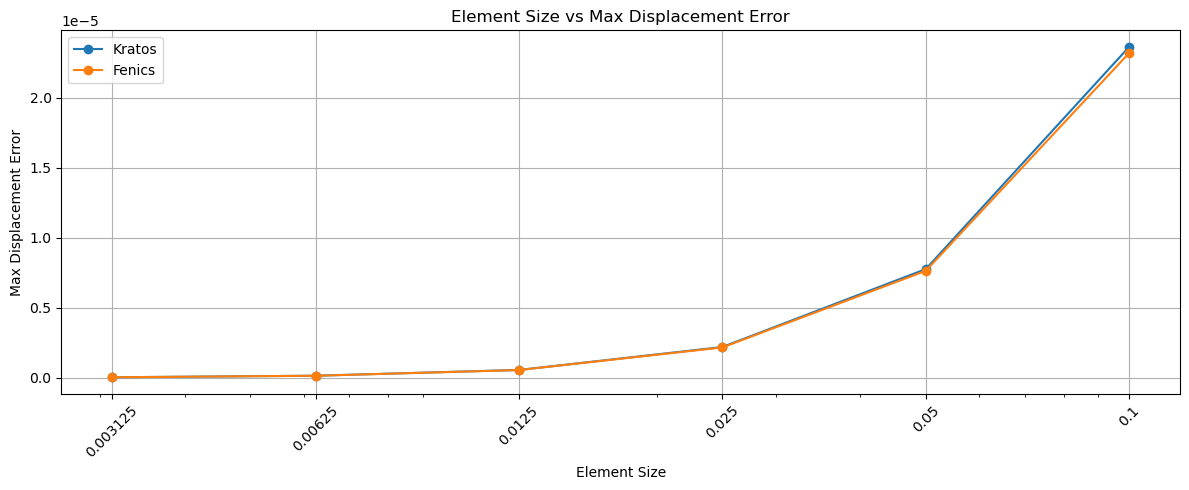

In [120]:
parameters = ["element_size", "isoparametric_element_degree"]
metrics = ["max_displacement_error"]

data = []

query_string = analyzer.build_dynamic_rohub_query(parameters, metrics, named_graphs.values())
df = rohub.query_sparql_endpoint(query_string, endpoint_url=rohub.settings.SPARQL_ENDPOINT)
result =  (df[df["isoparametric_element_degree"] == "1"].drop(columns=["isoparametric_element_degree"]))

analyzer.plot_provenance_graph_rohub(
    data=result.values.tolist(),
    x_axis_label="Element Size",
    y_axis_label="Max Displacement Error",
    group_index=0,
    x_axis_index=1,
    y_axis_index=2,
    title="Element Size vs Max Displacement Error",
)